# 16 - Per-LLM Neutral-to-Stanced Regression

This notebook studies what pushes each zero-shot LLM from `neutral` to a directional stance.
The emphasis is **interpretability**, not forecasting. For each model separately, we estimate
a binary regression where `stanced = 1` if the label is one of
`{dovish, mostly dovish, mostly hawkish, hawkish}` and `0` otherwise.

The notebook has three layers:

1. **Interpretable headline model** - clustered logit with three transparent feature buckets:
   macroeconomic language, forward guidance, and uncertainty/risk.
2. **Predictive robustness** - leakage-safe grouped holdout by meeting using dictionary controls,
   TF-IDF, and their combination.
3. **Direction appendix** - conditional `hawk` vs `dove` model on the subset of turns already
   classified as directional.

This is a **descriptive association** exercise. Strong coefficients mean that a language feature
is associated with a model leaving neutral more often, conditional on bank and year controls.


In [1]:
from __future__ import annotations

import math
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import statsmodels.formula.api as smf
    HAVE_STATSMODELS = True
except Exception as exc:  # pragma: no cover - notebook guardrail
    HAVE_STATSMODELS = False
    STATSMODELS_IMPORT_ERROR = exc

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path("/content")
else:
    ROOT = Path("..")

OUTPUT_DIR = ROOT / "output" / "stance"
NOTEBOOK_OUTPUT_DIR = OUTPUT_DIR / "threshold_regressions"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILES = {
    "deepseekv3": OUTPUT_DIR / "turn_predictions_deepseekv3.csv",
    "gemini25flash": OUTPUT_DIR / "turn_predictions_gemini25flash.csv",
    "gpt-4o": OUTPUT_DIR / "turn_predictions_gpt-4o.csv",
    "llama33": OUTPUT_DIR / "turn_predictions_llama33.csv",
    "mistrallarge_or": OUTPUT_DIR / "turn_predictions_mistrallarge_or.csv",
    "qwen25_72b": OUTPUT_DIR / "turn_predictions_qwen25_72b.csv",
}

MODEL_LABELS = {
    "deepseekv3": "DeepSeek V3",
    "gemini25flash": "Gemini 2.5 Flash",
    "gpt-4o": "GPT-4o Mini",
    "llama33": "Llama 3.3",
    "mistrallarge_or": "Mistral Large",
    "qwen25_72b": "Qwen 2.5 72B",
}

LABEL_ORDER = ["dovish", "mostly dovish", "neutral", "mostly hawkish", "hawkish"]
STANCED = {"dovish", "mostly dovish", "mostly hawkish", "hawkish"}
DOVE = {"dovish", "mostly dovish"}
HAWK = {"mostly hawkish", "hawkish"}
META_COLS = [
    "turn_uid",
    "bank",
    "doc_id",
    "date",
    "doc_type",
    "speaker",
    "speaker_role",
    "turn_idx",
    "text",
]
ANALYSIS_PATH = NOTEBOOK_OUTPUT_DIR / "llm_stance_threshold_analysis.csv"


## 1. Load and build the per-model analysis frame

We stack the six prediction files into one long panel with one row per `(turn, model)`.
The derived targets are:

- `stanced`: neutral vs any directional stance
- `direction_3way`: `dove / neutral / hawk`
- `direction_2way`: `dove / hawk` on the directional subset only
- `year`: extracted from the meeting date


In [3]:
def normalize_label(s: pd.Series) -> pd.Series:
    return s.astype(str).str.strip().str.lower()


def direction_3way_from_label(label: str) -> str:
    if label in DOVE:
        return "dove"
    if label in HAWK:
        return "hawk"
    return "neutral"


def direction_2way_from_label(label: str) -> str | None:
    if label in DOVE:
        return "dove"
    if label in HAWK:
        return "hawk"
    return None


def load_long_predictions() -> pd.DataFrame:
    frames = []
    for model_key, path in INPUT_FILES.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing prediction file: {path}")
        df = pd.read_csv(path)
        df["model_key"] = model_key
        df["label"] = normalize_label(df["label"])
        keep = df[META_COLS + ["model_key", "label", "confidence"]].copy()
        frames.append(keep)

    long_df = pd.concat(frames, ignore_index=True)
    long_df = long_df.drop_duplicates(subset=["turn_uid", "model_key"], keep="first").copy()
    long_df = long_df[long_df["label"].isin(LABEL_ORDER)].copy()
    long_df["year"] = long_df["date"].astype(str).str[:4].astype(int)
    long_df["stanced"] = long_df["label"].isin(STANCED).astype(int)
    long_df["direction_3way"] = long_df["label"].map(direction_3way_from_label)
    long_df["direction_2way"] = long_df["label"].map(direction_2way_from_label)
    long_df["model_name"] = long_df["model_key"].map(MODEL_LABELS)
    return long_df.sort_values(["model_key", "doc_id", "turn_idx", "turn_uid"]).reset_index(drop=True)


long_df = load_long_predictions()
long_df.to_csv(ANALYSIS_PATH, index=False)

summary = pd.DataFrame(
    {
        "rows": [len(long_df)],
        "turns": [long_df["turn_uid"].nunique()],
        "meetings": [long_df["doc_id"].nunique()],
        "years": [f"{long_df['year'].min()}-{long_df['year'].max()}"],
        "models": [long_df["model_key"].nunique()],
    }
)
display(summary)

stanced_summary = (
    long_df.groupby("model_name")
    .agg(
        n=("stanced", "size"),
        stanced_rate=("stanced", "mean"),
        neutral_rate=("stanced", lambda s: 1 - s.mean()),
    )
    .sort_values("neutral_rate", ascending=False)
)
display(stanced_summary.style.format({"stanced_rate": "{:.1%}", "neutral_rate": "{:.1%}"}))


,rows,turns,meetings,years,models
0,23832,3972,206,2015-2026,6


,n,stanced_rate,neutral_rate
model_name,,,
DeepSeek V3,3972,15.3%,84.7%
Qwen 2.5 72B,3972,16.1%,83.9%
GPT-4o Mini,3972,26.1%,73.9%
Mistral Large,3972,26.6%,73.4%
Gemini 2.5 Flash,3972,29.4%,70.6%
Llama 3.3,3972,30.2%,69.8%


## 2. Interpretable feature blocks

The main explanatory layer collapses the older dictionary work from notebook 15 into three
transparent buckets:

1. `macro_econ`
2. `forward_guidance`
3. `uncertainty_risk`

We also add simple text controls that could proxy for salience or ambiguity without relying on
opaque embeddings.


In [4]:
macro_econ_terms = {
    "activity", "demand", "economy", "economic", "employment", "financial", "gdp",
    "growth", "inflation", "labour", "market", "markets", "output", "prices",
    "productivity", "recession", "spending", "unemployment", "wage", "wages",
}

forward_guidance_terms = {
    "adjustment", "adjustments", "appropriate", "commitment", "continue", "currently",
    "expected", "expects", "expect", "future", "gradual", "gradually", "guidance",
    "horizon", "incoming", "intend", "intends", "maintain", "monitor", "normalisation",
    "normalization", "outlook", "pace", "path", "policy", "projection", "projections",
    "rates", "restrictive", "sequence", "target", "targets", "tightening", "trajectory",
}

uncertainty_risk_terms = {
    "balance", "careful", "conditional", "could", "depending", "headwinds", "may",
    "might", "monitor", "perhaps", "possible", "risk", "risks", "shock", "shocks",
    "stress", "uncertain", "uncertainties", "uncertainty", "unclear", "volatile",
    "volatility", "watch", "would",
}

hedge_terms = {"may", "might", "could", "would", "perhaps", "likely", "unlikely", "possible"}

dictionary_sheet = pd.DataFrame(
    {
        "macro_econ": pd.Series(sorted(macro_econ_terms)),
        "forward_guidance": pd.Series(sorted(forward_guidance_terms)),
        "uncertainty_risk": pd.Series(sorted(uncertainty_risk_terms)),
    }
)
display(dictionary_sheet)


,macro_econ,forward_guidance,uncertainty_risk
0,activity,adjustment,balance
1,demand,adjustments,careful
2,economic,appropriate,conditional
3,economy,commitment,could
4,employment,continue,depending
5,financial,currently,headwinds
6,gdp,expect,may
7,growth,expected,might
8,inflation,expects,monitor
9,labour,future,perhaps


In [5]:
TOKEN_RE = re.compile(r"[A-Za-z']+")
SENTENCE_RE = re.compile(r"[.!?]+")


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())


def dictionary_features(text: str) -> dict[str, float]:
    toks = tokenize(text)
    n_tokens = max(len(toks), 1)
    sentences = [s for s in SENTENCE_RE.split(str(text)) if s.strip()]
    n_sentences = max(len(sentences), 1)
    digit_chars = sum(ch.isdigit() for ch in str(text))

    macro_count = sum(tok in macro_econ_terms for tok in toks)
    fg_count = sum(tok in forward_guidance_terms for tok in toks)
    ur_count = sum(tok in uncertainty_risk_terms for tok in toks)
    hedge_count = sum(tok in hedge_terms for tok in toks)

    return {
        "token_count": len(toks),
        "token_count_log": math.log1p(len(toks)),
        "sentence_count": len(sentences),
        "avg_sentence_length": len(toks) / n_sentences,
        "has_question": int("?" in str(text)),
        "digit_share": digit_chars / max(len(str(text)), 1),
        "hedge_share": hedge_count / n_tokens,
        "macro_econ_count": macro_count,
        "forward_guidance_count": fg_count,
        "uncertainty_risk_count": ur_count,
        "macro_econ_share": macro_count / n_tokens,
        "forward_guidance_share": fg_count / n_tokens,
        "uncertainty_risk_share": ur_count / n_tokens,
    }


feature_df = pd.DataFrame([dictionary_features(text) for text in long_df["text"].astype(str)])
analysis = pd.concat([long_df.reset_index(drop=True), feature_df], axis=1)
analysis["year_centered"] = analysis["year"] - analysis["year"].min()

feature_cols_main = [
    "macro_econ_share",
    "forward_guidance_share",
    "uncertainty_risk_share",
]
feature_cols_controls = [
    "token_count_log",
    "avg_sentence_length",
    "has_question",
    "digit_share",
    "hedge_share",
]
feature_cols_all = feature_cols_main + feature_cols_controls

feature_summary = analysis[feature_cols_all].describe().T[["mean", "std", "min", "max"]]
display(feature_summary.style.format("{:.4f}"))


,mean,std,min,max
macro_econ_share,0.0189,0.0203,0.0000,0.5000
forward_guidance_share,0.0137,0.0155,0.0000,0.2500
uncertainty_risk_share,0.0120,0.0137,0.0000,0.2500
token_count_log,5.0533,1.1030,0.6931,7.6806
avg_sentence_length,20.0729,7.8852,0.5000,82.0000
has_question,0.2701,0.4440,0.0000,1.0000
digit_share,0.0020,0.0078,0.0000,0.2500
hedge_share,0.0081,0.0105,0.0000,0.1111


## 3. Headline clustered logit per LLM

The main specification is:

`stanced ~ macro + forward_guidance + uncertainty + text controls + C(bank) + C(year)`

Standard errors are clustered by `doc_id` to respect within-meeting dependence.
To compare magnitudes across features, we also report the odds ratio for a **one-standard-deviation**
increase and the average predicted-probability shift when moving from the 25th to the 75th percentile.


In [6]:
if not HAVE_STATSMODELS:
    raise ImportError(
        "statsmodels is required for the headline clustered logit. "
        "Install project dependencies first, e.g. `uv sync`, then rerun this notebook. "
        f"Original import error: {STATSMODELS_IMPORT_ERROR!r}"
    )


def fit_clustered_logit(df: pd.DataFrame, outcome: str, time_term: str = "C(year)"):
    formula = (
        f"{outcome} ~ macro_econ_share + forward_guidance_share + uncertainty_risk_share + "
        "token_count_log + avg_sentence_length + has_question + digit_share + hedge_share + "
        f"C(bank) + {time_term}"
    )
    model = smf.logit(formula, data=df)
    result = model.fit(
        disp=False,
        maxiter=200,
        cov_type="cluster",
        cov_kwds={"groups": df["doc_id"]},
    )
    return result


def percentile_shift(result, df: pd.DataFrame, feature: str, low_q: float = 0.25, high_q: float = 0.75):
    low = df[feature].quantile(low_q)
    high = df[feature].quantile(high_q)
    low_df = df.copy()
    high_df = df.copy()
    low_df[feature] = low
    high_df[feature] = high
    p_low = np.asarray(result.predict(low_df)).mean()
    p_high = np.asarray(result.predict(high_df)).mean()
    return {
        "feature": feature,
        "q25": low,
        "q75": high,
        "pred_p_q25": p_low,
        "pred_p_q75": p_high,
        "pp_shift": p_high - p_low,
    }


def summarize_headline_result(result, df: pd.DataFrame, model_name: str, outcome_col: str = "stanced"):
    coef_table = pd.DataFrame(
        {
            "coef": result.params,
            "se": result.bse,
            "z": result.tvalues,
            "p": result.pvalues,
        }
    )
    coef_table["odds_ratio"] = np.exp(coef_table["coef"])

    std_map = df[feature_cols_all].std().replace(0, np.nan).to_dict()
    coef_table["sd_x"] = coef_table.index.map(lambda name: std_map.get(name, np.nan))
    coef_table["odds_ratio_1sd"] = np.exp(coef_table["coef"] * coef_table["sd_x"])

    main_rows = coef_table.loc[feature_cols_main + feature_cols_controls].copy()
    main_rows.index.name = "term"

    shift_rows = pd.DataFrame([percentile_shift(result, df, feat) for feat in feature_cols_main]).set_index("feature")

    meta = pd.DataFrame(
        {
            "model": [model_name],
            "n": [len(df)],
            "meetings": [df["doc_id"].nunique()],
            "stanced_rate": [df[outcome_col].mean()],
            "neutral_rate": [1 - df[outcome_col].mean()],
            "pseudo_r2": [result.prsquared],
            "intercept": [result.params.get("Intercept", np.nan)],
        }
    )
    return meta, main_rows, shift_rows


headline_meta_rows = []
headline_coef_rows = []
headline_shift_rows = []
headline_results = {}

for model_key, model_name in MODEL_LABELS.items():
    sub = analysis[analysis["model_key"] == model_key].copy()
    result = fit_clustered_logit(sub, "stanced")
    headline_results[model_key] = result

    meta, coef_table, shift_table = summarize_headline_result(result, sub, model_name)
    headline_meta_rows.append(meta)

    coef_reset = coef_table.reset_index()
    coef_reset["model_key"] = model_key
    coef_reset["model_name"] = model_name
    headline_coef_rows.append(coef_reset)

    shift_reset = shift_table.reset_index()
    shift_reset["model_key"] = model_key
    shift_reset["model_name"] = model_name
    headline_shift_rows.append(shift_reset)

    display(Markdown(f"### {model_name}"))
    display(meta.style.format({"stanced_rate": "{:.1%}", "neutral_rate": "{:.1%}", "pseudo_r2": "{:.3f}", "intercept": "{:.3f}"}))
    display(
        coef_table.style.format(
            {
                "coef": "{:.3f}",
                "se": "{:.3f}",
                "z": "{:.2f}",
                "p": "{:.3g}",
                "odds_ratio": "{:.3f}",
                "sd_x": "{:.4f}",
                "odds_ratio_1sd": "{:.3f}",
            }
        )
    )
    display(
        shift_table.style.format(
            {
                "q25": "{:.4f}",
                "q75": "{:.4f}",
                "pred_p_q25": "{:.3f}",
                "pred_p_q75": "{:.3f}",
                "pp_shift": "{:+.3f}",
            }
        )
    )

headline_meta = pd.concat(headline_meta_rows, ignore_index=True).set_index("model")
headline_coefs = pd.concat(headline_coef_rows, ignore_index=True)
headline_shifts = pd.concat(headline_shift_rows, ignore_index=True)


### DeepSeek V3

,model,n,meetings,stanced_rate,neutral_rate,pseudo_r2,intercept
0,DeepSeek V3,3972,206,15.3%,84.7%,0.142,-7.545


,coef,se,z,p,odds_ratio,sd_x,odds_ratio_1sd
term,,,,,,,
macro_econ_share,11.554,2.257,5.12,3.05e-07,104196.211,0.0204,1.265
forward_guidance_share,28.353,3.706,7.65,2e-14,2058688414530.966,0.0155,1.552
uncertainty_risk_share,4.597,5.481,0.84,0.402,99.157,0.0137,1.065
token_count_log,0.718,0.083,8.70,3.34e-18,2.051,1.1031,2.209
avg_sentence_length,0.012,0.009,1.34,0.18,1.012,7.8861,1.096
has_question,-0.066,0.103,-0.65,0.518,0.936,0.4441,0.971
digit_share,18.711,4.992,3.75,0.000178,133714837.392,0.0078,1.156
hedge_share,-10.090,8.513,-1.19,0.236,0.000,0.0105,0.900


,q25,q75,pred_p_q25,pred_p_q75,pp_shift
feature,,,,,
macro_econ_share,0.0030,0.0291,0.130,0.163,+0.033
forward_guidance_share,0.0000,0.0208,0.106,0.168,+0.062
uncertainty_risk_share,0.0000,0.0175,0.147,0.156,+0.009


### Gemini 2.5 Flash

...

,q25,q75,pred_p_q25,pred_p_q75,pp_shift
feature,,,,,
macro_econ_share,0.0030,0.0291,0.214,0.289,+0.075
forward_guidance_share,0.0000,0.0208,0.197,0.290,+0.094
uncertainty_risk_share,0.0000,0.0175,0.279,0.261,-0.018


### Qwen 2.5 72B

,model,n,meetings,stanced_rate,neutral_rate,pseudo_r2,intercept
0,Qwen 2.5 72B,3972,206,16.1%,83.9%,0.155,-6.842


,coef,se,z,p,odds_ratio,sd_x,odds_ratio_1sd
term,,,,,,,
macro_econ_share,11.802,2.163,5.46,4.85e-08,133475.808,0.0204,1.271
forward_guidance_share,29.065,4.050,7.18,7.16e-13,4195629205285.090,0.0155,1.569
uncertainty_risk_share,-11.756,6.484,-1.81,0.0698,0.000,0.0137,0.851
token_count_log,0.679,0.076,8.99,2.39e-19,1.973,1.1031,2.116
avg_sentence_length,0.017,0.008,2.03,0.0424,1.017,7.8861,1.142
has_question,-0.034,0.117,-0.29,0.771,0.966,0.4441,0.985
digit_share,18.874,4.331,4.36,1.31e-05,157332761.653,0.0078,1.158
hedge_share,-0.041,10.080,-0.00,0.997,0.960,0.0105,1.000


,q25,q75,pred_p_q25,pred_p_q75,pp_shift
feature,,,,,
macro_econ_share,0.0030,0.0291,0.137,0.171,+0.034
forward_guidance_share,0.0000,0.0208,0.112,0.176,+0.065
uncertainty_risk_share,0.0000,0.0175,0.178,0.153,-0.024


## 4. Cross-model comparison

These views answer the substantive question directly:

- Which models have the highest baseline neutrality?
- Which models are most responsive to macroeconomic language?
- Which models are especially sensitive to forward-guidance or uncertainty language?


,n,meetings,stanced_rate,neutral_rate,pseudo_r2,intercept
model,,,,,,
DeepSeek V3,3972,206,15.3%,84.7%,0.142,-7.545
Qwen 2.5 72B,3972,206,16.1%,83.9%,0.155,-6.842
GPT-4o Mini,3972,206,26.1%,73.9%,0.154,-6.781
Mistral Large,3972,206,26.6%,73.4%,0.122,-6.026
Gemini 2.5 Flash,3972,206,29.4%,70.6%,0.153,-6.495
Llama 3.3,3972,206,30.2%,69.8%,0.141,-6.033


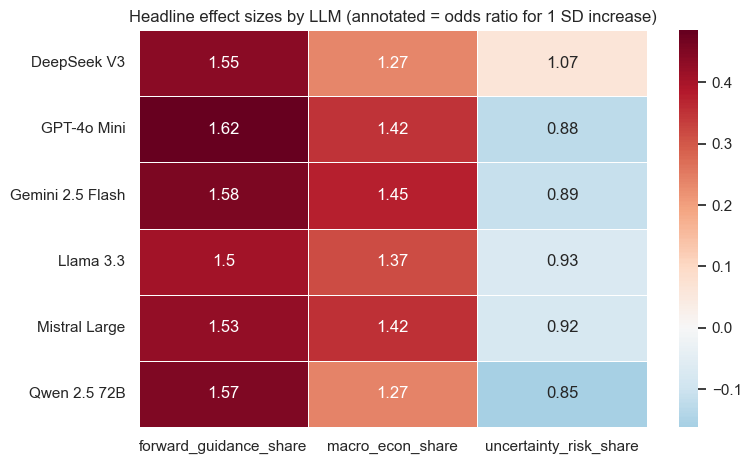

,forward_guidance_share,macro_econ_share,uncertainty_risk_share
DeepSeek V3,+0.062,+0.033,+0.009
GPT-4o Mini,+0.101,+0.071,-0.026
Gemini 2.5 Flash,+0.103,+0.082,-0.025
Llama 3.3,+0.095,+0.072,-0.016
Mistral Large,+0.094,+0.075,-0.018
Qwen 2.5 72B,+0.065,+0.034,-0.024


,model_name,odds_ratio_1sd,coef,p
0,GPT-4o Mini,1.624,31.294,2.86e-16
1,Gemini 2.5 Flash,1.579,29.489,3.86e-19
2,Qwen 2.5 72B,1.569,29.065,7.16e-13
3,DeepSeek V3,1.552,28.353,2e-14
4,Mistral Large,1.530,27.435,8.04e-15
5,Llama 3.3,1.501,26.189,3.27e-13
6,Gemini 2.5 Flash,1.454,18.397,2.26e-09
7,Mistral Large,1.422,17.299,8.53e-09
8,GPT-4o Mini,1.419,17.181,7.37e-09
9,Llama 3.3,1.375,15.631,1.28e-08


In [7]:
display(
    headline_meta.sort_values("neutral_rate", ascending=False).style.format(
        {"stanced_rate": "{:.1%}", "neutral_rate": "{:.1%}", "pseudo_r2": "{:.3f}", "intercept": "{:.3f}"}
    )
)

coef_focus = headline_coefs[headline_coefs["term"].isin(feature_cols_main)].copy()
or_1sd = coef_focus.pivot(index="model_name", columns="term", values="odds_ratio_1sd")
log_or_1sd = np.log(or_1sd)

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(log_or_1sd, annot=or_1sd.round(2), fmt="", cmap="RdBu_r", center=0, linewidths=0.4, ax=ax)
ax.set_title("Headline effect sizes by LLM (annotated = odds ratio for 1 SD increase)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

shift_focus = headline_shifts[headline_shifts["feature"].isin(feature_cols_main)].copy()
shift_rank = (
    shift_focus.pivot(index="model_name", columns="feature", values="pp_shift")
    .rename_axis(index=None, columns=None)
)
display(shift_rank.style.format("{:+.3f}"))

responsiveness_rank = (
    coef_focus.assign(abs_log_or_1sd=lambda d: np.abs(np.log(d["odds_ratio_1sd"])))
    .sort_values(["term", "abs_log_or_1sd"], ascending=[True, False])
    .groupby("term")[["model_name", "odds_ratio_1sd", "coef", "p"]]
    .head(len(MODEL_LABELS))
)
display(responsiveness_rank.reset_index(drop=True).style.format({"odds_ratio_1sd": "{:.3f}", "coef": "{:.3f}", "p": "{:.3g}"}))


## 5. Grouped holdout robustness

The headline model is descriptive and uses the full sample. To check that the patterns are not
purely meeting-specific, we also run a leakage-safe grouped holdout by `doc_id`.

Benchmarks:

- dictionary + text controls
- TF-IDF unigram/bigram
- dictionary + controls + TF-IDF


In [8]:
def grouped_holdout_indices(df: pd.DataFrame, random_state: int = 42, test_size: float = 0.25):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(df, y=df["stanced"], groups=df["doc_id"]))
    return train_idx, test_idx


def make_dict_pipeline():
    return Pipeline(
        steps=[
            ("pre", ColumnTransformer(
                transformers=[
                    ("num", StandardScaler(), feature_cols_all),
                    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["bank", "year"]),
                ],
                remainder="drop",
            )),
            ("logit", LogisticRegression(max_iter=5000, class_weight="balanced", C=1.0)),
        ]
    )


def make_tfidf_pipeline():
    return Pipeline(
        steps=[
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=5000,
                    ngram_range=(1, 2),
                    min_df=5,
                    stop_words="english",
                    sublinear_tf=True,
                ),
            ),
            ("logit", LogisticRegression(max_iter=5000, class_weight="balanced", C=0.5)),
        ]
    )


def make_hybrid_pipeline():
    return Pipeline(
        steps=[
            (
                "pre",
                ColumnTransformer(
                    transformers=[
                        ("num", StandardScaler(), feature_cols_all),
                        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["bank", "year"]),
                        (
                            "txt",
                            TfidfVectorizer(
                                max_features=4000,
                                ngram_range=(1, 2),
                                min_df=5,
                                stop_words="english",
                                sublinear_tf=True,
                            ),
                            "text",
                        ),
                    ],
                    remainder="drop",
                ),
            ),
            ("logit", LogisticRegression(max_iter=5000, class_weight="balanced", C=0.5)),
        ]
    )


def evaluate_binary_pipeline(pipeline, train_df: pd.DataFrame, test_df: pd.DataFrame, text_only: bool = False):
    if text_only:
        pipeline.fit(train_df["text"], train_df["stanced"])
        pred = pipeline.predict_proba(test_df["text"])[:, 1]
    else:
        pipeline.fit(train_df, train_df["stanced"])
        pred = pipeline.predict_proba(test_df)[:, 1]
    return {
        "auc": roc_auc_score(test_df["stanced"], pred),
        "pr_auc": average_precision_score(test_df["stanced"], pred),
        "pred": pred,
    }


robustness_rows = []
tfidf_term_rows = []

for model_key, model_name in MODEL_LABELS.items():
    sub = analysis[analysis["model_key"] == model_key].copy().reset_index(drop=True)
    train_idx, test_idx = grouped_holdout_indices(sub)
    train_df = sub.iloc[train_idx].copy()
    test_df = sub.iloc[test_idx].copy()

    models = {
        "dict_controls": (make_dict_pipeline(), False),
        "tfidf": (make_tfidf_pipeline(), True),
        "dict_plus_tfidf": (make_hybrid_pipeline(), False),
    }

    for spec_name, (pipe, text_only) in models.items():
        eval_out = evaluate_binary_pipeline(pipe, train_df, test_df, text_only=text_only)
        robustness_rows.append(
            {
                "model_name": model_name,
                "spec": spec_name,
                "n_train": len(train_df),
                "n_test": len(test_df),
                "meetings_train": train_df["doc_id"].nunique(),
                "meetings_test": test_df["doc_id"].nunique(),
                "auc": eval_out["auc"],
                "pr_auc": eval_out["pr_auc"],
            }
        )

    tfidf_full = make_tfidf_pipeline().fit(sub["text"], sub["stanced"])
    vec = tfidf_full.named_steps["tfidf"]
    clf = tfidf_full.named_steps["logit"]
    coefs = pd.Series(clf.coef_[0], index=vec.get_feature_names_out()).sort_values()

    top_neutral = coefs.head(8).reset_index()
    top_neutral.columns = ["term", "coef"]
    top_neutral["direction"] = "toward_neutral"
    top_neutral["model_name"] = model_name

    top_stanced = coefs.tail(8).sort_values(ascending=False).reset_index()
    top_stanced.columns = ["term", "coef"]
    top_stanced["direction"] = "toward_stanced"
    top_stanced["model_name"] = model_name

    tfidf_term_rows.append(pd.concat([top_neutral, top_stanced], ignore_index=True))

robustness_df = pd.DataFrame(robustness_rows)
tfidf_terms_df = pd.concat(tfidf_term_rows, ignore_index=True)

display(
    robustness_df.pivot(index="model_name", columns="spec", values=["auc", "pr_auc"]).style.format("{:.3f}")
)


In [9]:
focus_terms = (
    tfidf_terms_df.sort_values(["model_name", "direction", "coef"], ascending=[True, True, False])
    .groupby(["model_name", "direction"])
    .head(5)
    .reset_index(drop=True)
)
display(focus_terms.style.format({"coef": "{:.3f}"}))


,term,coef,direction,model_name
0,framework,-0.777,toward_neutral,DeepSeek V3
1,investment,-0.793,toward_neutral,DeepSeek V3
2,issues,-0.806,toward_neutral,DeepSeek V3
3,sort,-0.857,toward_neutral,DeepSeek V3
4,fiscal,-0.862,toward_neutral,DeepSeek V3
5,inflation,3.626,toward_stanced,DeepSeek V3
6,rates,2.455,toward_stanced,DeepSeek V3
7,accommodative,2.223,toward_stanced,DeepSeek V3
8,accommodation,1.935,toward_stanced,DeepSeek V3
9,rate,1.884,toward_stanced,DeepSeek V3


## 6. Appendix: conditional hawk-vs-dove direction

The main question is whether a model leaves neutral at all. This appendix checks whether the
same feature blocks also help explain **which way** a directional turn is coded.

Because the directional subset is much smaller, some model-year cells contain only hawkish or only
dovish observations. To avoid singular year fixed effects, this appendix keeps the same bank controls
but replaces `C(year)` with a linear `year_centered` trend.


,n,meetings,hawk_rate,dove_rate,pseudo_r2,intercept
model,,,,,,
DeepSeek V3,609,175,47.3%,52.7%,0.118,-0.781
Gemini 2.5 Flash,1167,201,44.0%,56.0%,0.120,-1.338
GPT-4o Mini,1037,197,34.5%,65.5%,0.087,-3.162
Llama 3.3,1198,199,44.1%,55.9%,0.081,-0.943
Mistral Large,1056,200,48.0%,52.0%,0.077,0.015
Qwen 2.5 72B,639,176,58.8%,41.2%,0.139,-0.826


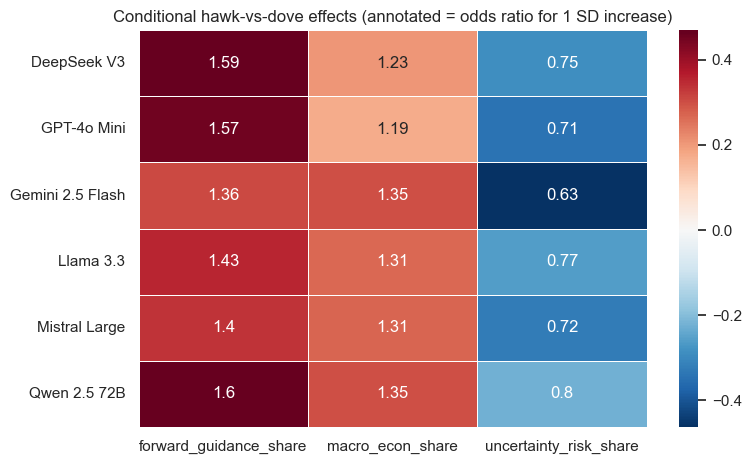

In [10]:
direction_rows = []
direction_coef_rows = []

for model_key, model_name in MODEL_LABELS.items():
    sub = analysis[(analysis["model_key"] == model_key) & (analysis["direction_2way"].notna())].copy()
    sub["hawk_vs_dove"] = (sub["direction_2way"] == "hawk").astype(int)

    result = fit_clustered_logit(
        sub.rename(columns={"hawk_vs_dove": "staged_outcome_for_fit"}),
        "staged_outcome_for_fit",
        time_term="year_centered",
    )
    direction_df = sub.rename(columns={"hawk_vs_dove": "staged_outcome_for_fit"})
    meta, coef_table, shift_table = summarize_headline_result(
        result=result,
        df=direction_df,
        model_name=model_name,
        outcome_col="staged_outcome_for_fit",
    )
    meta = meta.rename(columns={"stanced_rate": "hawk_rate", "neutral_rate": "dove_rate"})
    direction_rows.append(meta)

    coef_reset = coef_table.reset_index()
    coef_reset["model_name"] = model_name
    direction_coef_rows.append(coef_reset)

direction_meta = pd.concat(direction_rows, ignore_index=True).set_index("model")
direction_coefs = pd.concat(direction_coef_rows, ignore_index=True)

display(direction_meta.style.format({"hawk_rate": "{:.1%}", "dove_rate": "{:.1%}", "pseudo_r2": "{:.3f}", "intercept": "{:.3f}"}))

direction_focus = direction_coefs[direction_coefs["term"].isin(feature_cols_main)].copy()
direction_or = direction_focus.pivot(index="model_name", columns="term", values="odds_ratio_1sd")

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(np.log(direction_or), annot=direction_or.round(2), fmt="", cmap="RdBu_r", center=0, linewidths=0.4, ax=ax)
ax.set_title("Conditional hawk-vs-dove effects (annotated = odds ratio for 1 SD increase)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## Reading guide

A practical way to read the results is:

1. Start with the **neutral-rate table** to see which models are hardest to move off neutral.
2. Use the **headline odds-ratio heatmap** to see which feature bucket each model responds to most.
3. Check the **probability-shift table** for effect sizes on an intuitive probability scale.
4. Treat the **grouped holdout metrics** as robustness, not the main estimand.
5. Use the **direction appendix** only to ask whether the same language that triggers stance also
   explains hawkish vs dovish direction.
